# Missing Data Handling on Horse Colic Dataset

In [53]:
import numpy as np
import pandas as pd

import statsmodels.formula.api as smf
from scipy.stats import norm

import matplotlib.pyplot as plt

#### **Multiple Imputation**
- **Imputation**: Making multiple imputations for each missing value
- **Analysis**: Making inferences based on each complete dataset with different imputed values
- **Pooling**: Combining inferences to obtain final parameter estimates

Imputation helper functions

In [54]:
def impute(data, value):
    """
    Function to impute a missing data (array-like) with a certain value
    
    :param data: array-like, the data with missing values
    :param value: float/int (or array-like), the value to use for imputing missing values
    :return imputed_array: array-like, the imputed data
    """
    # Check for each element in data
    # return True if it's a missing value (represented as NaN in numpy)
    # return False otherwise.
    data = np.asarray(data, dtype=float)
    bool_nan = np.isnan(data)

    # Replace the missing values with the given value (scalar or array-like)
    imputed_array = np.where(bool_nan, value, data)

    return imputed_array

Impute Function Usage Example

# Missing Data Handling in Horse Colic Dataset

The Horse Colic Dataset contains medical records of horses experiencing colic (abdominal pain). This dataset has many clinical variables (vital signs, physical examination results, lab results) that are **missing** (marked with `?` in the original file), making it suitable for demonstrating how to handle *missing data*.

- This case focuses on demonstrating **Handling Multiple Missing Variables** using **Iterative Regression Imputation**, which occurs when more than one predictor/target variable has overlapping missing values.
- We will compare the performance of the regression models:
1. Complete Case Analysis (CCA)
2. Iterative Regression Imputation
- We will then compare the R-squared and standard error of the two approaches.

### Load Data

The original dataset has no headers, so we named the columns according to the UCI Horse Colic Dataset documentation.

In [55]:
# column names as per UCI Horse Colic Dataset documentation
columns = ['surgery', 'age', 'hospital_number', 'rectal_temperature', 'pulse',
           'respiratory_rate', 'temp_extremities', 'peripheral_pulse', 'mucous_membrane',
           'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distension',
           'nasogastric_tube', 'nasogastric_reflux', 'nasogastric_reflux_ph',
           'rectal_exam_feces', 'abdomen', 'packed_cell_volume', 'total_protein',
           'abdomo_appearance', 'abdomo_protein', 'outcome', 'surgical_lesion',
           'lesion_1', 'lesion_2', 'lesion_3', 'cp_data']

# load data, mark '?' in the file is considered a missing value (NaN)
horse = pd.read_csv('horse-colic.data', header=None, sep=r'\s+', na_values='?', names=columns)
horse.shape

(300, 28)

### Inspect What's Missing

In [56]:
horse.isna().sum()

surgery                    1
age                        0
hospital_number            0
rectal_temperature        60
pulse                     24
respiratory_rate          58
temp_extremities          56
peripheral_pulse          69
mucous_membrane           47
capillary_refill_time     32
pain                      55
peristalsis               44
abdominal_distension      56
nasogastric_tube         104
nasogastric_reflux       106
nasogastric_reflux_ph    247
rectal_exam_feces        102
abdomen                  118
packed_cell_volume        29
total_protein             33
abdomo_appearance        165
abdomo_protein           198
outcome                    1
surgical_lesion            0
lesion_1                   0
lesion_2                   0
lesion_3                   0
cp_data                    0
dtype: int64

Calculate the percentage of missing in each column

In [57]:
(horse.isna().sum()/horse.shape[0]).sort_values(ascending=False)

nasogastric_reflux_ph    0.823333
abdomo_protein           0.660000
abdomo_appearance        0.550000
abdomen                  0.393333
nasogastric_reflux       0.353333
nasogastric_tube         0.346667
rectal_exam_feces        0.340000
peripheral_pulse         0.230000
rectal_temperature       0.200000
respiratory_rate         0.193333
abdominal_distension     0.186667
temp_extremities         0.186667
pain                     0.183333
mucous_membrane          0.156667
peristalsis              0.146667
total_protein            0.110000
capillary_refill_time    0.106667
packed_cell_volume       0.096667
pulse                    0.080000
surgery                  0.003333
outcome                  0.003333
hospital_number          0.000000
age                      0.000000
surgical_lesion          0.000000
lesion_1                 0.000000
lesion_2                 0.000000
lesion_3                 0.000000
cp_data                  0.000000
dtype: float64

- `surgery` is only missing one row, so we'll remove it to ensure all categorical predictor variables are complete.
- Our focus: `packed_cell_volume` (PCV) and `total_protein` (TP), two numeric lab variables that both have missing values ​​and are often used together to assess the level of dehydration/shock in colicky horses.

In [58]:
# remove 1 missing row in 'surgery' (used as complete predictor)
horse = horse.dropna(subset=['surgery']).reset_index(drop=True)
horse.shape

(299, 28)

## Handle Multiple Variable Missing

### Iterative Regression Imputation

- Interactive regression imputation is a method that iteratively imputes each missing value in a variable, using other fully observed predictors.
- We will use this method to impute `packed_cell_volume` and `total_protein` simultaneously, as both have missing values.

What happens if there are missing rows in more than 1 variable at a time?

In [59]:
missing_pcv_tp = (horse['packed_cell_volume'].isna() & horse['total_protein'].isna())

horse[missing_pcv_tp].shape

(26, 28)

There are some lines where `packed_cell_volume` and `total_protein` are both missing.

#### Starting Value Imputation: Simple Random Imputation

We initiate initial values ​​using a simple approach, namely simple random imputation, as the initial imputation values ​​of our missing data.

Helper function to perform simple random imputation

In [60]:
def random_imp(a):

    a = np.asarray(a, dtype=float)

    # Array contains booleans, True if element a is missing, False otherwise
    missing = np.isnan(a)

    # Number of missing values
    n_missing = missing.sum()

    # observation a that is not missing
    a_obs = a[~missing]

    # copy from a
    imputed = a.copy()

    # impute missing values ​​with non-missing random observations
    imputed[missing] = np.random.choice(a_obs, size=n_missing)

    return imputed

Perform simple random imputation on `packed_cell_volume` and `total_protein`

In [61]:
np.random.seed(1)

horse['pcv_imp'] = random_imp(horse['packed_cell_volume'])
horse['tp_imp'] = random_imp(horse['total_protein'])

We have two new variables that impute the missing `packed cell volume` and `total_protein` with random values ​​from the observed data.

In [62]:
init_horse = horse[missing_pcv_tp][['packed_cell_volume', 'total_protein', 'pcv_imp', 'tp_imp']].copy()
init_horse

,packed_cell_volume,total_protein,pcv_imp,tp_imp
5,NaN,NaN,52.0,6.6
17,NaN,NaN,47.0,6.4
25,NaN,NaN,40.0,6.7
28,NaN,NaN,65.0,7.2
39,NaN,NaN,33.0,6.5
51,NaN,NaN,44.0,7.7
72,NaN,NaN,46.0,7.8
101,NaN,NaN,69.0,6.2
113,NaN,NaN,40.0,76.0
130,NaN,NaN,35.0,9.0


#### Iterative Imputation

- Next, impute `packed_cell_volume` first using the regression prediction with the other complete predictors, as well as the completed `tp_imp` from simple random imputation.
- After `packed_cell_volume` is imputed, we impute `total_protein` using the regression prediction, with the updated `packed_cell_volume` value after imputation.
- Repeat this step until convergence. For simplicity, we use n = 10 iterations.
- The predictors used are the fully observed variables: `age`, `surgery`, `surgical_lesion`, `cp_data`

In [63]:
# inisiasi n iterasi
n_loop = 10

# iterasi
for s in range(n_loop):

    # Build a regression model to predict the lost packed cell volume
    # # Using tp_imp (total protein imputed in the previous iteration)
    model_pcv = smf.ols('packed_cell_volume ~ age + surgery + surgical_lesion + cp_data + tp_imp',
                        horse).fit()

    # predict packed_cell_volume
    pred_pcv = model_pcv.predict(horse)

    # impute missing packed_cell_volume with regression prediction results
    horse['pcv_imp'] = impute(horse['packed_cell_volume'].values, pred_pcv.values)

    # Build a regression model to predict the lost total protein
    # using the updated pcv_imp
    model_tp = smf.ols('total_protein ~ age + surgery + surgical_lesion + cp_data + pcv_imp',
                       horse).fit()

    # predict total_protein
    pred_tp = model_tp.predict(horse)

    # impute missing total_protein with regression prediction results
    horse['tp_imp'] = impute(horse['total_protein'].values, pred_tp.values)

The above code is not the most efficient; it is written this way to demonstrate the general concept of iterative imputation.

In [64]:
iterative_imputation_horse = horse[missing_pcv_tp][['packed_cell_volume', 'total_protein', 'pcv_imp', 'tp_imp']]
iterative_imputation_horse

,packed_cell_volume,total_protein,pcv_imp,tp_imp
5,NaN,NaN,43.936064,35.070914
17,NaN,NaN,43.936064,35.070914
25,NaN,NaN,43.936064,35.070914
28,NaN,NaN,42.238743,45.508315
39,NaN,NaN,41.192013,24.057195
51,NaN,NaN,49.396104,7.850341
72,NaN,NaN,47.090477,33.299695
101,NaN,NaN,47.090477,33.299695
113,NaN,NaN,49.396104,7.850341
130,NaN,NaN,47.090477,33.299695


Compare the histograms of the initial conditions (using simple random imputation) and after iterative imputation.

**Packed Cell Volume (PCV)**

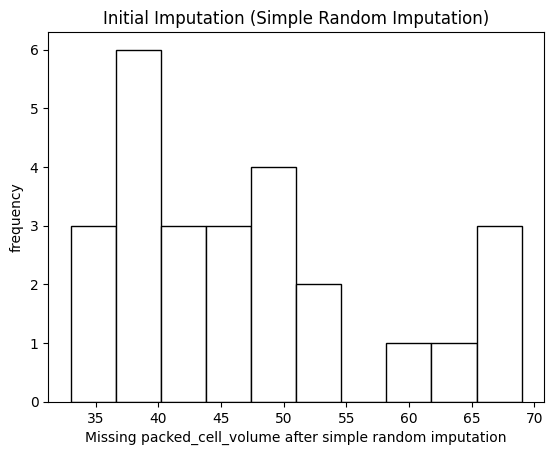

In [65]:
plt.hist(init_horse['pcv_imp'], color='white', edgecolor='black')
plt.xlabel('Missing packed_cell_volume after simple random imputation')
plt.ylabel('frequency')
plt.title('Initial Imputation (Simple Random Imputation)')
plt.show()

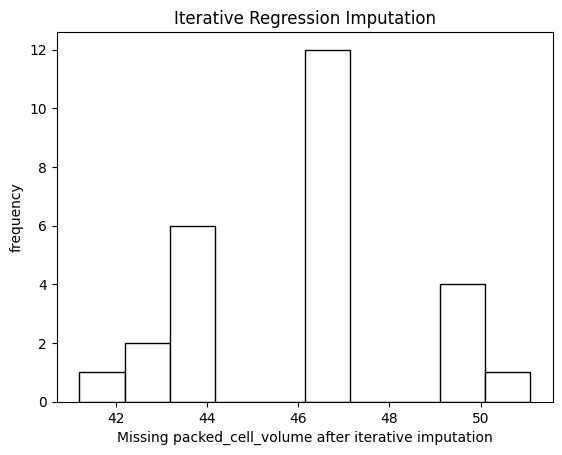

In [66]:
plt.hist(iterative_imputation_horse['pcv_imp'], color='white', edgecolor='black')
plt.xlabel('Missing packed_cell_volume after iterative imputation')
plt.ylabel('frequency')
plt.title('Iterative Regression Imputation')
plt.show()

**Total Protein (TP)**

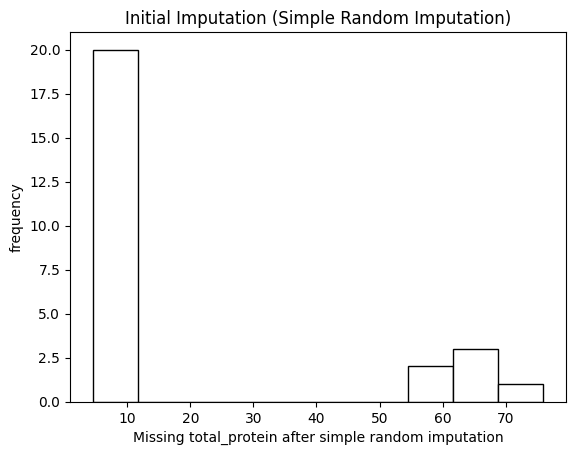

In [67]:
plt.hist(init_horse['tp_imp'], color='white', edgecolor='black')
plt.xlabel('Missing total_protein after simple random imputation')
plt.ylabel('frequency')
plt.title('Initial Imputation (Simple Random Imputation)')
plt.show()

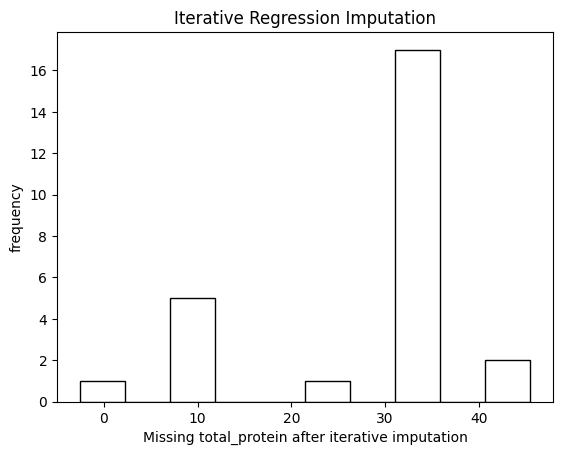

In [68]:
plt.hist(iterative_imputation_horse['tp_imp'], color='white', edgecolor='black')
plt.xlabel('Missing total_protein after iterative imputation')
plt.ylabel('frequency')
plt.title('Iterative Regression Imputation')
plt.show()

After iterative imputation, the imputed values ​​follow the pattern of relationships between variables (rather than just random samples), so their distribution differs from the initial conditions of random imputation.

#### Performance and Standard Error Comparison

Finally, let us compare the evaluation of Complete Case Analysis and Iterative Imputation, with the target variable `packed_cell_volume` and including `total_protein` as a predictor.

##### Complete Case Analysis

**Build a regression model for the CCA dataset**

In [69]:
# remove rows that have missing values ​​in packed_cell_volume OR total_protein
horse_cca = horse.dropna(subset=['packed_cell_volume', 'total_protein']).copy()
horse_cca.shape

(263, 30)

- Use the data after we remove missing values ​​to build the model
- Include the variable `total_protein`

In [70]:
# Create an OLS model object and fit the model
model_cca = smf.ols('packed_cell_volume ~ age + surgery + surgical_lesion + cp_data + total_protein',
                    horse_cca).fit()

**Save Model Evaluation**

In [71]:
model_cca_rsquared = model_cca.rsquared
model_cca_rsquared

np.float64(0.06264345673947891)

In [72]:
model_cca_se = model_cca.bse
model_cca_se

Intercept          3.109299
age                0.284040
surgery            1.639953
surgical_lesion    1.670146
cp_data            1.479733
total_protein      0.026270
dtype: float64

##### Dataset after Iterative Regression Imputation

**Build a regression model for the dataset after Iterative Regression Imputation**

- Use `pcv_imp` as outcome and include `tp_imp` as predictor

In [73]:
# Create an OLS model object and fit the model
model_iter_reg = smf.ols('pcv_imp ~ age + surgery + surgical_lesion + cp_data + tp_imp',
                         horse).fit()

**Save Model Evaluation**

In [74]:
model_iter_reg_rsquared = model_iter_reg.rsquared
model_iter_reg_rsquared

np.float64(0.07495319863151728)

In [75]:
model_iter_reg_se = model_iter_reg.bse
model_iter_reg_se

Intercept          2.810804
age                0.260209
surgery            1.460421
surgical_lesion    1.489815
cp_data            1.349672
tp_imp             0.024926
dtype: float64

##### Comparison

In [76]:
rsquared = pd.DataFrame(data={'rsquared': [model_cca_rsquared, model_iter_reg_rsquared]},
                        index=['cca', 'iterative'])
rsquared

,rsquared
cca,0.062643
iterative,0.074953


The model using iterative regression imputation to handle missing `packed_cell_volume` and `total_protein` provided higher explained variance than Complete Case Analysis.

In [77]:
arr_se = np.array([model_cca_se.values, model_iter_reg_se.values]).T

standard_error = pd.DataFrame(data=arr_se,
                              columns=['cca', 'iterative'],
                              index=model_cca.params.index)
standard_error

,cca,iterative
Intercept,3.109299,2.810804
age,0.284040,0.260209
surgery,1.639953,1.460421
surgical_lesion,1.670146,1.489815
cp_data,1.479733,1.349672
total_protein,0.026270,0.024926


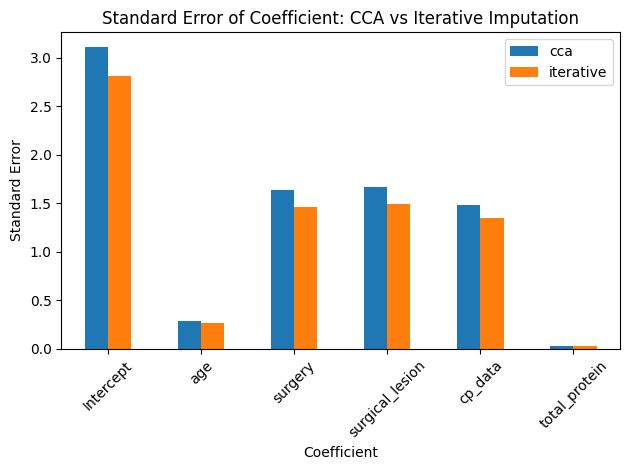

In [78]:
standard_error.plot(kind='bar')
plt.title('Standard Error of Coefficient: CCA vs Iterative Imputation')
plt.xlabel('Coefficient')
plt.ylabel('Standard Error')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Models with iterative regression imputation tend to provide smaller standard errors on most coefficients than Complete Case Analysis.

**Conclusion**

On the horse-colic dataset, iterative regression imputation to handle missing variables on two variables at once (`packed_cell_volume` and `total_protein`) provided better performance and estimates (higher R-squared and generally smaller standard errors) than Complete Case Analysis, while maintaining a larger sample size for analysis.